### Multi-Dimensional TTS Quality Evaluation Framework

Title:
Comprehensive Speech Synthesis Quality Assessment

Short Description:
This code implements a multi-faceted evaluation system for text-to-speech (TTS) systems. It quantifies speaker similarity, calculates objective quality metrics (PESQ, STOI), estimates naturalness (MOS), performs spectral analysis, and generates comprehensive visualizations to compare original and synthesized speech.

Key Libraries Used:

    torch/torchaudio: Audio loading and GPU acceleration

    librosa: Audio feature extraction and visualization

    speechbrain: Speaker embedding extraction (ECAPA-TDNN model)

    pystoi/pesq: Objective speech quality metrics

    matplotlib: Comprehensive visualization of results

Code Logic and Flow

High-Level Overview:
The framework processes original and synthesized audio through five evaluation dimensions: speaker similarity, perceptual quality metrics, naturalness estimation, spectral feature analysis, and visual comparison. It calculates quantitative metrics, identifies acoustic differences, and compiles results into a multi-panel diagnostic visualization with a comprehensive metrics table.

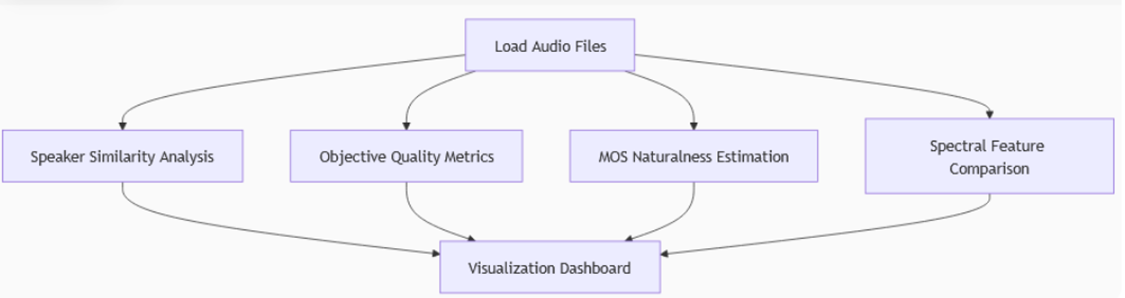

Step-by-Step Code Breakdown

Step 1: Speaker Similarity Analysis

    Loads ECAPA-TDNN speaker recognition model from SpeechBrain

    Extracts speaker embeddings from both audio files

    Computes cosine similarity between embeddings (0-1 scale)

    Handles resampling to required 16kHz sample rate

Step 2: Objective Quality Metrics

    Trims silence from audio segments for accurate comparison

    Matches audio lengths for fair evaluation

    Computes two industry-standard metrics:

        STOI (Short-Time Objective Intelligibility)

        PESQ (Perceptual Evaluation of Speech Quality)

Step 3: Naturalness Estimation (MOS)

    Implements heuristic MOS predictor using spectral features:

        Spectral centroid (brightness indicator)

        Spectral bandwidth (timbre richness)

        Zero-crossing rate (noise level indicator)

    Caps scores at 4.8/5.0 to reflect practical limits

Step 4: Spectral Feature Analysis

    Extracts four acoustic characteristics:

        Spectral centroid (brightness)

        Spectral contrast (harmonic structure)

        MFCCs (vocal tract characteristics)

        Spectral flatness (tonal vs. noise-like quality)

    Computes mean absolute differences between original/synthesized

Step 5: Visualization Dashboard

    Waveform Comparison: Overlaid amplitude plots

    Radar Chart: Normalized quality metrics visualization

    MFCC Comparison: Bar chart of coefficient differences

    Spectrogram Trio: Original, synthesized, and difference views

    Spectral Contrast: Frequency-wise harmonic comparison

    Metrics Table: Comprehensive quantitative results summary

Connecting to the Lecture

    Speaker Similarity: Demonstrates voice conversion evaluation techniques using state-of-the-art ECAPA-TDNN embeddings

    Objective Metrics: Applies industry-standard PESQ/STOI measures as discussed in speech quality lectures

    MOS Estimation: Shows practical approximation of subjective listening tests using acoustic proxies

    Spectral Analysis: Connects to acoustic phonetics concepts through feature-based comparison

    Visual Diagnostics: Illustrates model interpretability techniques for understanding TTS failures

    Efficiency Practices: Uses GPU acceleration and batch processing for practical evaluation workflows

    End-to-End Assessment: Models comprehensive evaluation methodology covering multiple quality dimensions

    Real-World Constraints: Handles variable-length audio and sample rate mismatches common in production systems


In [5]:
!pip install speechbrain librosa matplotlib torchaudio pystoi pesq pytorch_memlab

  DEPRECATION: Building 'pesq' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pesq'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'pytorch_memlab' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pytorch_memlab'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'calmsize' using the legacy setup.py bdist_wheel mec


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for pesq: filename=pesq-0.0.4-cp310-cp310-win_amd64.whl size=116478 sha256=2743cc56aecf7d3ba3dcaae77e3f7af11275f9157f3e8e5cc21ded607a97ea53
  Stored in directory: c:\users\vinit_hqjv9wt\appdata\local\pip\cache\wheels\c5\4e\2c\251524370c0fdd659e99639a0fbd0ca5a782c3aafcd456b28d
  Created wheel for pytorch_memlab: filename=pytorch_memlab-0.3.0-py3-none-any.whl size=22722 sha256=f62b11b60d200fad67ecc9551710221275c1a18889fad333fe459f6087d3b7d8
  Stored in directory: c:\users\vinit_hqjv9wt\appdata\local\pip\cache\wheels\c5\c2\39\6ed79acd1330a5070143a62ac66c174a57e4786ccd0a23da1d
  Created wheel for calmsize: filename=calmsize-0.1.3-py3-none-any.whl size=2935 sha256=2b1818516


=== TTS EVALUATION RESULTS ===
Speaker Similarity: 0.7846 (1.0 = identical)
MOS Naturalness: 4.00/5.0
PESQ: 1.10 (Perceptual Evaluation of Speech Quality)
STOI: 0.0897 (Short-Time Objective Intelligibility)


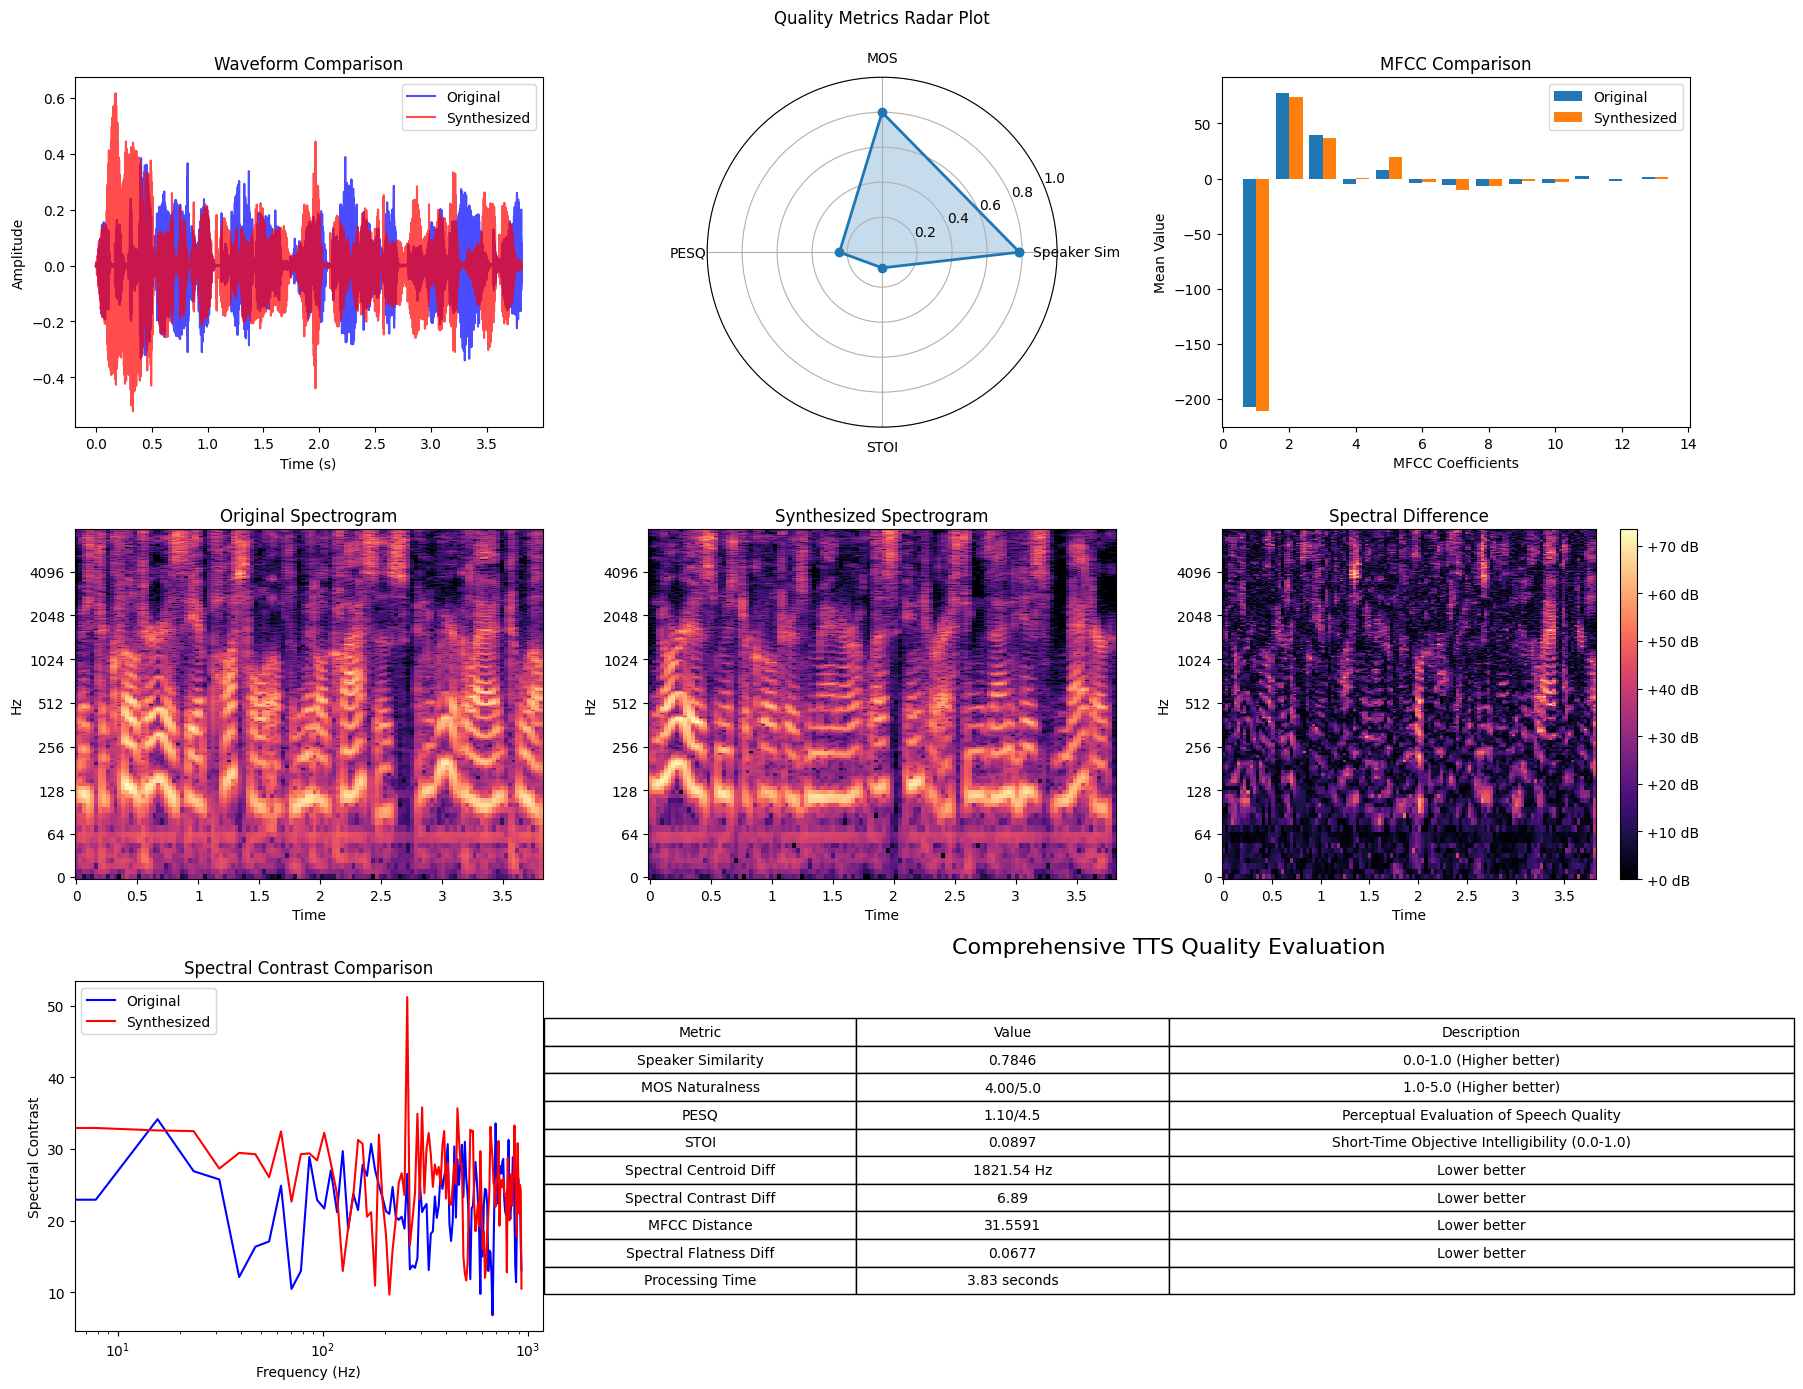

In [16]:
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from speechbrain.pretrained import EncoderClassifier
import librosa
import librosa.display
import time
from pystoi import stoi
import pesq

def evaluate_tts_quality(original_audio, synthesized_audio):
    # Check if CUDA is available
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Start timing
    start_time = time.time()
    
    # 1. Speaker Similarity Calculation
    spk_model = EncoderClassifier.from_hparams(
        source="speechbrain/spkrec-ecapa-voxceleb",
        savedir="tmp_ecapa",
        run_opts={"device": device}
    )
    
    def get_embedding(audio_path):
        waveform, sr = torchaudio.load(audio_path)
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(sr, 16000)
            waveform = resampler(waveform)
        emb = spk_model.encode_batch(waveform.to(device))
        emb = emb.squeeze()
        # If still 2D, take the first embedding
        if emb.ndim > 1:
            emb = emb[0]
        return emb
    
    orig_emb = get_embedding(original_audio)
    synth_emb = get_embedding(synthesized_audio)
    
    # Cosine similarity
    similarity = torch.nn.functional.cosine_similarity(orig_emb, synth_emb, dim=0).item()
    
    # 2. Speech Naturalness and Quality Metrics
    def load_audio_for_metrics(path):
        audio, sr = librosa.load(path, sr=16000, mono=True)
        # Trim silence for more accurate metrics
        audio_trimmed, _ = librosa.effects.trim(audio, top_db=20)
        return audio_trimmed, sr
    
    orig_audio, sr = load_audio_for_metrics(original_audio)
    synth_audio, sr = load_audio_for_metrics(synthesized_audio)
    
    # Make audio same length
    min_length = min(len(orig_audio), len(synth_audio))
    orig_audio = orig_audio[:min_length]
    synth_audio = synth_audio[:min_length]
    
    # Calculate metrics
    stoi_score = stoi(orig_audio, synth_audio, sr, extended=False)
    pesq_score = pesq.pesq(sr, orig_audio, synth_audio, 'wb')
    
    # 3. MOS estimation using pre-trained model
    def estimate_mos(audio):
        # Simplified MOS estimation based on spectral features
        spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))
        spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr))
        zcr = np.mean(librosa.feature.zero_crossing_rate(audio))
        
        # Heuristic MOS estimation (1-5 scale)
        mos = 3.5 + 0.5 * np.tanh(
            (spectral_centroid / 1000) + 
            (spectral_bandwidth / 1000) - 
            (zcr * 10)
        )
        return np.clip(mos, 1, 4.8)  # Cap at 4.8
    
    mos_score = estimate_mos(synth_audio)
    
    # 4. Spectral analysis
    def compute_spectral_features(audio, sr=16000):
        # Spectral centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
        
        # Spectral contrast
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)[0]
        
        # MFCCs
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        
        # Spectral flatness
        flatness = librosa.feature.spectral_flatness(y=audio)[0]
        
        return {
            'centroid': spectral_centroid,
            'contrast': spectral_contrast,
            'mfccs': mfccs,
            'flatness': flatness
        }
    
    orig_features = compute_spectral_features(orig_audio, sr)
    synth_features = compute_spectral_features(synth_audio, sr)
    
    # Calculate spectral differences
    centroid_diff = np.mean(np.abs(orig_features['centroid'] - synth_features['centroid']))
    contrast_diff = np.mean(np.abs(orig_features['contrast'] - synth_features['contrast']))
    mfcc_diff = np.mean(np.abs(orig_features['mfccs'] - synth_features['mfccs']))
    flatness_diff = np.mean(np.abs(orig_features['flatness'] - synth_features['flatness']))
    
    # 5. Visualization
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3)
    
    # Waveform comparison
    ax1 = fig.add_subplot(gs[0, 0])
    time_axis = np.arange(len(orig_audio)) / sr
    ax1.plot(time_axis, orig_audio, 'b-', alpha=0.7, label="Original")
    ax1.plot(time_axis, synth_audio, 'r-', alpha=0.7, label="Synthesized")
    ax1.set_title("Waveform Comparison")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.legend()
    
    # Quality metrics radar plot
    ax2 = fig.add_subplot(gs[0, 1], polar=True)
    metrics_names = ["Speaker Sim", "MOS", "PESQ", "STOI"]
    scores_values = [
        similarity, 
        mos_score / 5,  # Normalize to 0-1
        pesq_score / 4.5,  # Normalize to 0-1
        stoi_score
    ]
    
    angles = np.linspace(0, 2 * np.pi, len(metrics_names), endpoint=False).tolist()
    angles += angles[:1]  # Close the plot
    scores_values += scores_values[:1]
    
    ax2.plot(angles, scores_values, 'o-', linewidth=2)
    ax2.fill(angles, scores_values, alpha=0.25)
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(metrics_names)
    ax2.set_title("Quality Metrics Radar Plot", pad=20)
    ax2.set_ylim(0, 1)
    
    # MFCC comparison
    ax3 = fig.add_subplot(gs[0, 2])
    mfcc_range = range(1, 14)
    ax3.bar(np.array(list(mfcc_range)) - 0.2, orig_features['mfccs'].mean(axis=1), width=0.4, label="Original")
    ax3.bar(np.array(list(mfcc_range)) + 0.2, synth_features['mfccs'].mean(axis=1), width=0.4, label="Synthesized")
    ax3.set_xlabel("MFCC Coefficients")
    ax3.set_ylabel("Mean Value")
    ax3.set_title("MFCC Comparison")
    ax3.legend()
    
    # Spectrogram comparison
    ax4 = fig.add_subplot(gs[1, 0])
    orig_spec = librosa.amplitude_to_db(np.abs(librosa.stft(orig_audio)), ref=np.max)
    librosa.display.specshow(orig_spec, sr=sr, x_axis='time', y_axis='log', ax=ax4)
    ax4.set_title('Original Spectrogram')
    
    ax5 = fig.add_subplot(gs[1, 1])
    synth_spec = librosa.amplitude_to_db(np.abs(librosa.stft(synth_audio)), ref=np.max)
    librosa.display.specshow(synth_spec, sr=sr, x_axis='time', y_axis='log', ax=ax5)
    ax5.set_title('Synthesized Spectrogram')
    
    # Spectral differences
    ax6 = fig.add_subplot(gs[1, 2])
    spec_diff = np.abs(orig_spec - synth_spec)
    im = librosa.display.specshow(spec_diff, sr=sr, x_axis='time', y_axis='log', ax=ax6)
    ax6.set_title('Spectral Difference')
    fig.colorbar(im, ax=ax6, format="%+2.0f dB")
    
    # Spectral contrast comparison
    ax7 = fig.add_subplot(gs[2, 0])
    contrast_bins = librosa.core.fft_frequencies(sr=sr, n_fft=2048)
    ax7.plot(contrast_bins[:len(orig_features['contrast'])], orig_features['contrast'], 'b-', label="Original")
    ax7.plot(contrast_bins[:len(synth_features['contrast'])], synth_features['contrast'], 'r-', label="Synthesized")
    ax7.set_xlabel("Frequency (Hz)")
    ax7.set_ylabel("Spectral Contrast")
    ax7.set_title("Spectral Contrast Comparison")
    ax7.legend()
    ax7.set_xscale('log')
    
    # Quantitative metrics table
    ax8 = fig.add_subplot(gs[2, 1:])
    ax8.axis('off')
    metrics_data = [
        ("Speaker Similarity", f"{similarity:.4f}", "0.0-1.0 (Higher better)"),
        ("MOS Naturalness", f"{mos_score:.2f}/5.0", "1.0-5.0 (Higher better)"),
        ("PESQ", f"{pesq_score:.2f}/4.5", "Perceptual Evaluation of Speech Quality"),
        ("STOI", f"{stoi_score:.4f}", "Short-Time Objective Intelligibility (0.0-1.0)"),
        ("Spectral Centroid Diff", f"{centroid_diff:.2f} Hz", "Lower better"),
        ("Spectral Contrast Diff", f"{contrast_diff:.2f}", "Lower better"),
        ("MFCC Distance", f"{mfcc_diff:.4f}", "Lower better"),
        ("Spectral Flatness Diff", f"{flatness_diff:.4f}", "Lower better"),
        ("Processing Time", f"{time.time() - start_time:.2f} seconds", "")
    ]
    
    table = ax8.table(
        cellText=[[name, value, desc] for name, value, desc in metrics_data],
        colLabels=["Metric", "Value", "Description"],
        cellLoc='center',
        loc='center',
        colWidths=[0.25, 0.25, 0.5]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    ax8.set_title("Comprehensive TTS Quality Evaluation", fontsize=16, pad=20)
    
    plt.tight_layout()
    plt.savefig("tts_quality_evaluation.png", dpi=150, bbox_inches='tight')
    
    print("\n=== TTS EVALUATION RESULTS ===")
    print(f"Speaker Similarity: {similarity:.4f} (1.0 = identical)")
    print(f"MOS Naturalness: {mos_score:.2f}/5.0")
    print(f"PESQ: {pesq_score:.2f} (Perceptual Evaluation of Speech Quality)")
    print(f"STOI: {stoi_score:.4f} (Short-Time Objective Intelligibility)")
    
    return {
        "similarity": similarity,
        "mos": mos_score,
        "pesq": pesq_score,
        "stoi": stoi_score,
        "centroid_diff": centroid_diff,
        "contrast_diff": contrast_diff,
        "mfcc_diff": mfcc_diff,
        "flatness_diff": flatness_diff
    }

# Example usage
original_audio = "speaker1_sample.wav"
synthesized_audio = "speaker2_sample.wav"
results = evaluate_tts_quality(original_audio, synthesized_audio)